# Week 2 Assignment

### name: Lukas Linss
### student_id: 25332477
### id:7-7-7

In [8]:
import warnings

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

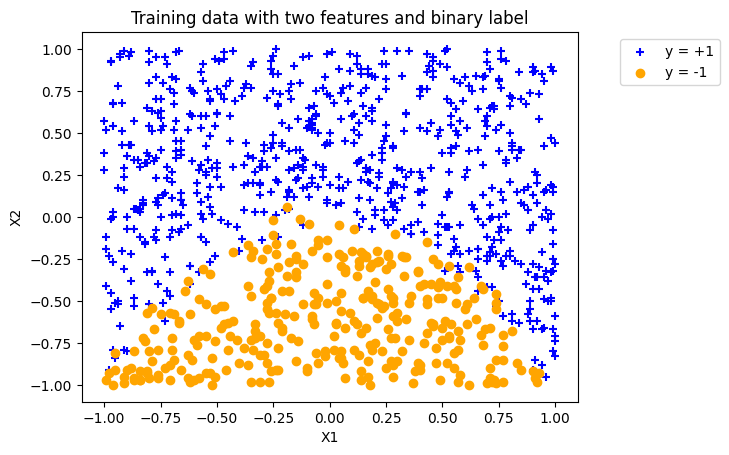

In [9]:
df = pd.read_csv('week_2_dataset.csv',skiprows=1, header=None, names=['X1', 'X2', 'Y'])

y_positive_df = df[df['Y'] == 1]
y_negative_df = df[df['Y'] == -1]

plt.scatter(x=y_positive_df['X1'], y=y_positive_df['X2'], color='blue', marker='+', label='y = +1')
plt.scatter(x=y_negative_df['X1'], y=y_negative_df['X2'], color='orange', marker='o', label='y = -1')

plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Training data with two features and binary label')
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1))
plt.show()

In [10]:
df.insert(2, 'X3', df['X1'].map(lambda x: x ** 2))
df.insert(3, 'X4', df['X2'].map(lambda x: x ** 2))

X = df[['X1', 'X2', 'X3', 'X4']].to_numpy()
y = df['Y'].to_numpy()

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)
model = LogisticRegression(penalty='l2', fit_intercept=True, C=4)
model.fit(x_train, y_train)

print(f'coefficients: {model.coef_[0]}, intercept {model.intercept_[0]}')

coefficients: [ 0.31823388  9.42984454  8.80238895 -1.19833096], intercept 0.5294799113702117


In [11]:
pred = model.predict(x_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

          -1       0.94      0.95      0.95       103
           1       0.97      0.97      0.97       197

    accuracy                           0.96       300
   macro avg       0.96      0.96      0.96       300
weighted avg       0.96      0.96      0.96       300



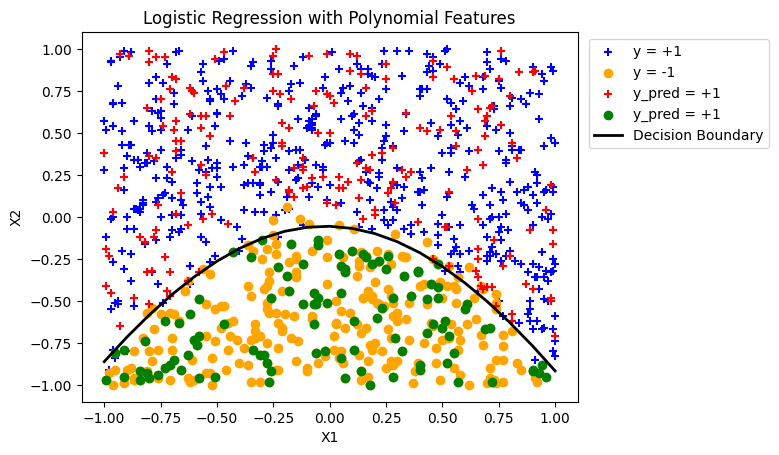

In [15]:
plt.xlabel('X1')
plt.ylabel('X2')
pos_pred, neg_pred = x_test[pred == 1], x_test[pred == -1]
plt.scatter(x=y_positive_df['X1'], y=y_positive_df['X2'], color='blue', marker='+', label='y = +1')
plt.scatter(x=y_negative_df['X1'], y=y_negative_df['X2'], color='orange', marker='o', label='y = -1')

plt.scatter(x=pos_pred.T[0], y=pos_pred.T[1], marker='+', color='red', label='y_pred = +1')
plt.scatter(x=neg_pred.T[0], y=neg_pred.T[1], marker='o', color='green', label='y_pred = +1')

weights = [*model.intercept_, *model.coef_[0]]

def x2_plus(x_1, w):
    sqrt_inner = w[2]**2 - 4*w[4] * (w[3]*x_1**2 + w[1]* x_1 + w[0])
    return (-w[2] + np.sqrt(sqrt_inner)) / (2*w[4])

x1 = np.arange(-1, 1.1, 0.1)
plt.plot(x1, x2_plus(x1,weights), color='black', label='Decision Boundary', linewidth=2)

plt.title('Logistic Regression with Polynomial Features')
plt.legend(loc='upper right', bbox_to_anchor=(1.4, 1))
plt.show()

In [13]:
class MostCommonClassifer:
    def __init__(self):
        self.most_common = None

    def fit(self, _, y_label):
        self.most_common = 1 if len(y_label[y_label == 1]) > len(y_label[y_label==-1]) else -1
        return self

    def predict(self, x):
        return np.array([self.most_common] * len(x))

mcc = MostCommonClassifer().fit(x_train, y_train)
mcc_pred = mcc.predict(x_test)
print(classification_report(y_test, mcc_pred))

              precision    recall  f1-score   support

          -1       0.00      0.00      0.00       103
           1       0.66      1.00      0.79       197

    accuracy                           0.66       300
   macro avg       0.33      0.50      0.40       300
weighted avg       0.43      0.66      0.52       300

